In [2]:
import numpy as np
import pandas as pd

# Set a random seed for reproducible results
np.random.seed(42)
num_patients = 500

# Generate Synthetic Clinical Baseline Features
age = np.random.normal(loc=55, scale=12, size=num_patients).astype(int)
gender = np.random.choice([0, 1], size=num_patients, p=[0.35, 0.65]) # More males statistically

# Initialize blank arrays for biomarkers and diagnosis
afp = np.zeros(num_patients)
alt = np.zeros(num_patients)
bilirubin = np.zeros(num_patients)
diagnosis = np.random.choice([0, 1], size=num_patients, p=[0.5, 0.5])

# Simulate realistic physiological splits based on the diagnosis
for i in range(num_patients):
    if diagnosis[i] == 1: # Cancer Patient Profile
        afp[i] = np.random.exponential(scale=350) + np.random.uniform(20, 100)
        alt[i] = np.random.normal(loc=120, scale=40)
        bilirubin[i] = np.random.normal(loc=2.8, scale=1.1)
    else: # Control Group Profile (Healthy or benign cirrhosis)
        afp[i] = np.random.uniform(2, 15)
        alt[i] = np.random.normal(loc=35, scale=12)
        bilirubin[i] = np.random.normal(loc=0.9, scale=0.3)

# Enforce strict positive limits for biological measurements
afp = np.clip(afp, 1.5, None)
alt = np.clip(alt, 10, None)
bilirubin = np.clip(bilirubin, 0.2, None)

# Package into a clean dataframe
clinical_df = pd.DataFrame({
    "Patient_ID": range(1001, 1001 + num_patients),
    "Age": age,
    "Gender": gender,
    "AFP_Level_ngML": np.round(afp, 2),
    "ALT_Enzyme_U_L": np.round(alt, 2),
    "Total_Bilirubin_mgdL": np.round(bilirubin, 2),
    "Diagnosis_HCC": diagnosis
})

# Display the first 10 rows of your clinical trial
clinical_df.head(10)

,Patient_ID,Age,Gender,AFP_Level_ngML,ALT_Enzyme_U_L,Total_Bilirubin_mgdL,Diagnosis_HCC
0,1001,60,1,232.81,135.54,5.54,1
1,1002,53,1,13.95,38.02,0.90,0
2,1003,62,1,704.01,102.46,4.08,1
3,1004,73,1,13.41,38.21,1.00,0
4,1005,52,1,12.27,28.91,0.83,0
5,1006,52,0,214.41,78.54,4.24,1
6,1007,73,0,14.68,48.03,1.04,0
7,1008,64,0,138.72,119.00,3.70,1
8,1009,49,0,407.40,120.41,1.36,1
9,1010,61,0,209.72,95.62,2.59,1


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_12868\4163257584.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Diagnosis_HCC", y="AFP_Level_ngML", data=clinical_df, palette="Set2")


<Figure size 640x480 with 0 Axes>

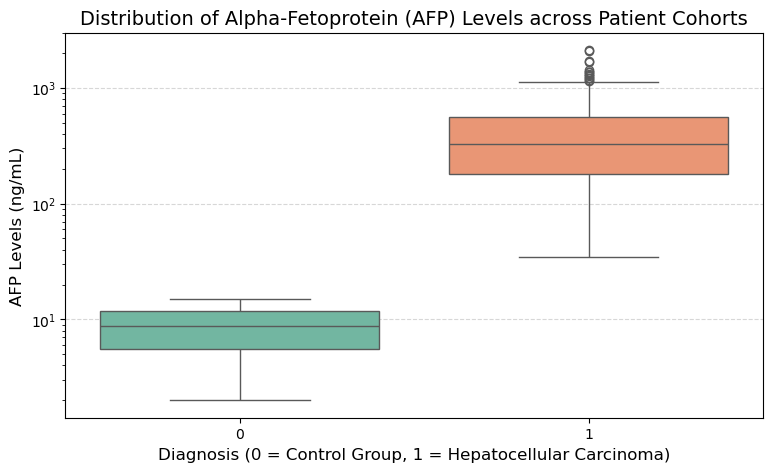

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clear any stuck background plots
plt.clf()

# 2. Generate the boxplot visualization
plt.figure(figsize=(9, 5))
sns.boxplot(x="Diagnosis_HCC", y="AFP_Level_ngML", data=clinical_df, palette="Set2")

# 3. Add professional labels
plt.title("Distribution of Alpha-Fetoprotein (AFP) Levels across Patient Cohorts", fontsize=14)
plt.xlabel("Diagnosis (0 = Control Group, 1 = Hepatocellular Carcinoma)", fontsize=12)
plt.ylabel("AFP Levels (ng/mL)", fontsize=12)
plt.yscale("log") # Using log scale to handle the massive cancer spikes
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Explicitly force the graph onto your laptop screen
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Separate our data into Features (X) and the Target label we want to predict (y)
X = clinical_df[["Age", "Gender", "AFP_Level_ngML", "ALT_Enzyme_U_L", "Total_Bilirubin_mgdL"]]
y = clinical_df["Diagnosis_HCC"]

# 2. Split into 80% Training data and 20% Testing data (Fixed parameter name here!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Random Forest Classifier model
ml_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Train the AI using our training data partition
ml_model.fit(X_train, y_train)

# 5. Force the model to take its final exam by predicting the hidden test set
predictions = ml_model.predict(X_test)

# 6. Print out the performance grading report
print("=== MACHINE LEARNING MODEL PERFORMANCE ===")
print(f"Overall Model Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%\n")
print(classification_report(y_test, predictions))

=== MACHINE LEARNING MODEL PERFORMANCE ===
Overall Model Accuracy: 100.00%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        58

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_12868\2491834970.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance_Score", y="Biomarker", data=importances_df, palette="Oranges_r")


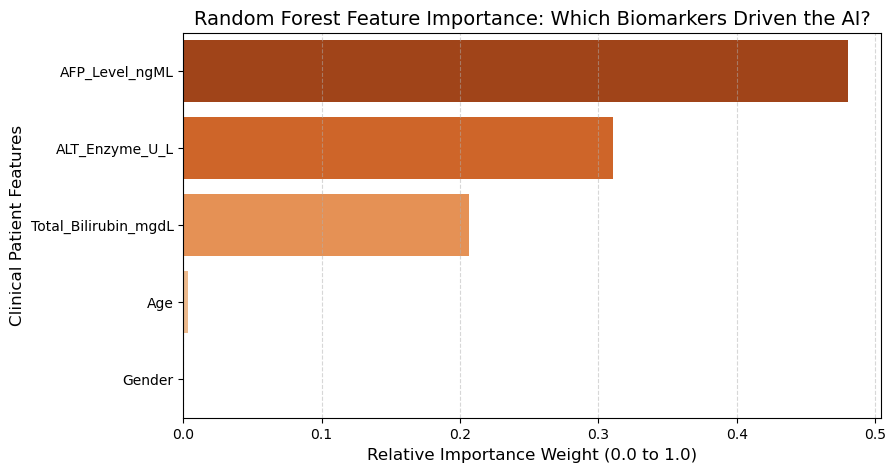

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract how much weight the AI gave to each biomarker
importances = ml_model.feature_importances_
feature_names = ["Age", "Gender", "AFP_Level_ngML", "ALT_Enzyme_U_L", "Total_Bilirubin_mgdL"]

# 2. Organize into a clean dataframe and sort it
importances_df = pd.DataFrame({
    "Biomarker": feature_names,
    "Importance_Score": importances
}).sort_values(by="Importance_Score", ascending=False)

# 3. Create a beautiful horizontal bar chart
plt.figure(figsize=(9, 5))
sns.barplot(x="Importance_Score", y="Biomarker", data=importances_df, palette="Oranges_r")

# 4. Add professional titles and clean layout lines
plt.title("Random Forest Feature Importance: Which Biomarkers Driven the AI?", fontsize=14)
plt.xlabel("Relative Importance Weight (0.0 to 1.0)", fontsize=12)
plt.ylabel("Clinical Patient Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Show the chart on your laptop screen
plt.show()

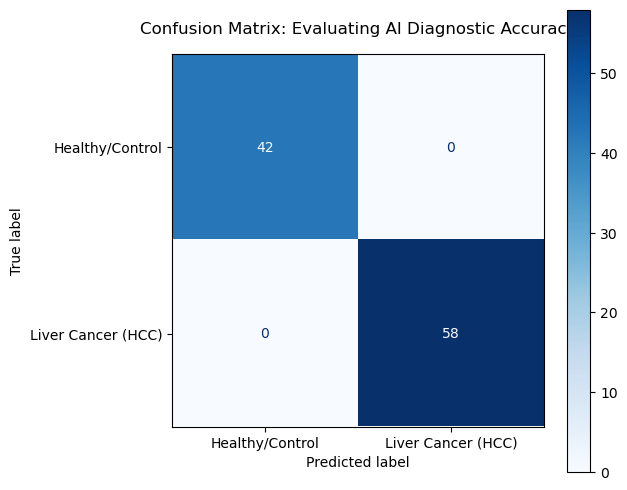

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Compute the raw mathematical confusion matrix values
cm = confusion_matrix(y_test, predictions)

# 2. Set up the visual display grid
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy/Control", "Liver Cancer (HCC)"])

# 3. Plot it with a clean blue color map
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

# 4. Add titles and remove background grid clutter
plt.title("Confusion Matrix: Evaluating AI Diagnostic Accuracy", fontsize=12, pad=15)
ax.grid(False)

# Show the graphic on your laptop screen
plt.show()